In [40]:
%pylab inline
plt.rc('font', family='serif')
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{mathrsfs}')
plt.rc('text', usetex=True)
import seaborn as sns
from scipy.integrate import quad
import pandas as pd
import scipy
import scipy.signal
from scipy.signal import fftconvolve
from tqdm import tqdm
import arviz as az

sns.set(style='ticks', context='notebook', font='serif', 
        font_scale=1.5, palette='deep')
rc_params = {'backend': 'pdf',
             'axes.labelsize': 24,
             'axes.titlesize': 32,
             'font.size': 18,
             'legend.fontsize': 18,
             'xtick.labelsize': 24,
             'ytick.labelsize': 24,
             'font.family': 'serif',
             'font.sans-serif': ['Bitstream Vera Sans'],
             'font.serif': ['Times New Roman'],
             'text.usetex':True,
            }

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/home/haowen.zhong/.conda/envs/Hierfit/lib/python3.11/site-packages/IPython/core/magics/pylab.py:162: UserWarning: pylab import has clobbered these variables: ['diff']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


# Fig 1 & Fig 2
## $$P_{jk}\approx 2T\sum_i P(id f)\mathrm{sinc}[\pi(i d f-j\delta f)T]\mathrm{sinc}[\pi(id f-k\delta j)T]d f$$

## Band-limited white noise
$$P(f)=C,~(|f|\leqslant f_0=\frac{1}{\tau_0})$$
$$T\gg \tau_0$$
One must have $\Delta f\lesssim\mathrm{min}(\delta f,\delta f_0)$

In [3]:
def sinc(x):
    return 1.0 if x == 0.0 else np.sin(x)/x

def P_OU(f, tau):
    f0 = 1/tau
    if np.abs(f) <= f0:
        PSD = 1
    else:
        PSD = 0
    return PSD

def Pjk_quad(j, k, T, tau):
    fj = j / T
    fk = k / T

    def integrand(f):
        return (P_OU(f, tau)
                * sinc(np.pi*T*(f - fj))
                * sinc(np.pi*T*(f - fk)))*2*T

    val, err = quad(
        integrand,
        -np.inf, np.inf,
        epsabs=1e-20,
        epsrel=1e-20,
        limit=1000
    )
    return val, err

/tmp/ipykernel_2341/3766792439.py:24: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, err = quad(


Text(0.5, 1.0, '$P_{\\ell m}/\\sqrt{P_{\\ell\\ell}P_{mm}}$')

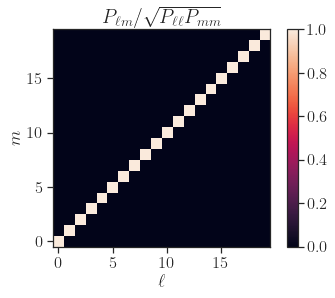

In [4]:
tau = 1e-2
T = 1

Pjk_mat = np.zeros([20, 20])
err_mat = np.zeros([20, 20])
for j in range(20):
    for k in range(20):
        int_result = Pjk_quad(j, k, T, tau)
        Pjk_mat[j, k] = int_result[0]
        err_mat[j, k] = int_result[1]

diag_vals = np.diag(Pjk_mat)
denom = np.sqrt(np.outer(diag_vals, diag_vals))
corr_matrix = Pjk_mat / denom
corr_matrix = np.nan_to_num(corr_matrix)

plt.imshow(corr_matrix.T, origin="lower")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$m$")
plt.colorbar()
plt.title(r"$P_{\ell m}/\sqrt{P_{\ell\ell}P_{mm}}$", fontsize=20)

/tmp/ipykernel_2341/3766792439.py:24: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  val, err = quad(


Text(0.5, 1.0, '$P_{\\ell m}/\\sqrt{P_{\\ell\\ell}P_{mm}}$')

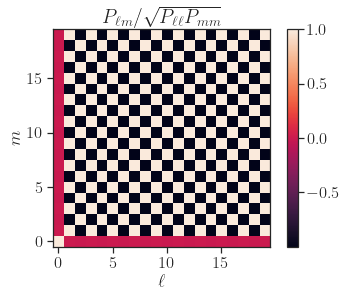

In [5]:
tau = 100
T = 1

Pjk_mat = np.zeros([20, 20])
err_mat = np.zeros([20, 20])
for j in range(20):
    for k in range(20):
        int_result = Pjk_quad(j, k, T, tau)
        Pjk_mat[j, k] = int_result[0]
        err_mat[j, k] = int_result[1]

diag_vals = np.diag(Pjk_mat)
denom = np.sqrt(np.outer(diag_vals, diag_vals))
corr_matrix = Pjk_mat / denom
corr_matrix = np.nan_to_num(corr_matrix)

plt.imshow(corr_matrix.T, origin="lower")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$m$")
plt.colorbar()
plt.title(r"$P_{\ell m}/\sqrt{P_{\ell\ell}P_{mm}}$", fontsize=20)

### Gaussian $C(f)$

$$P(f)=e^{-\frac{1}{2}\left(\frac{f}{f_0}\right)^2}, f_0=\frac{1}{\tau}$$

In [6]:
def P_OU(f, tau):
    PSD = np.exp(-0.5 * (f*tau)**2)
    return PSD


def Pjk_quad(j, k, T, tau):
    fj = j / T
    fk = k / T

    def integrand(f):
        return (P_OU(f, tau)
                * sinc(np.pi*T*(f - fj))
                * sinc(np.pi*T*(f - fk)))
    val, err = quad(
        integrand,
        -np.inf, np.inf,
        epsabs=1e-20,
        epsrel=1e-20,
        limit=1000
    )
    return val, err

/tmp/ipykernel_2341/3720833554.py:20: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, err = quad(


Text(0.5, 1.0, '$P_{\\ell m}/\\sqrt{P_{\\ell\\ell}P_{mm}}$')

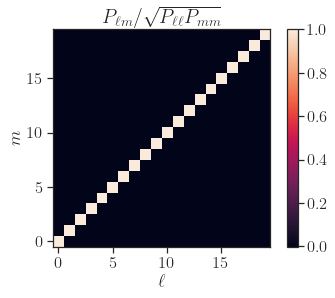

In [7]:
tau = 1e-2
T = 1

Pjk_mat = np.zeros([20, 20])
err_mat = np.zeros([20, 20])
for j in range(20):
    for k in range(20):
        int_result = Pjk_quad(j, k, T, tau)
        Pjk_mat[j, k] = int_result[0]
        err_mat[j, k] = int_result[1]

diag_vals = np.diag(Pjk_mat)
denom = np.sqrt(np.outer(diag_vals, diag_vals))
corr_matrix = Pjk_mat / denom
corr_matrix = np.nan_to_num(corr_matrix)
plt.imshow(corr_matrix.T, origin="lower")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$m$")
plt.colorbar()
plt.title(r"$P_{\ell m}/\sqrt{P_{\ell\ell}P_{mm}}$", fontsize=20)

/tmp/ipykernel_2341/3720833554.py:20: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, err = quad(


Text(0.5, 1.0, '$P_{\\ell m}/\\sqrt{P_{\\ell\\ell}P_{mm}}$')

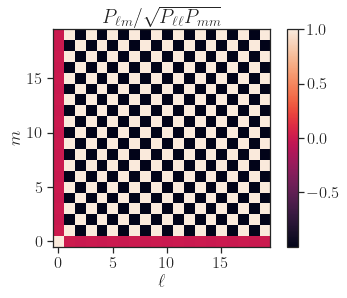

In [8]:
tau = 100
T = 1

Pjk_mat = np.zeros([20, 20])
err_mat = np.zeros([20, 20])
for j in range(20):
    for k in range(20):
        int_result = Pjk_quad(j, k, T, tau)
        Pjk_mat[j, k] = int_result[0]
        err_mat[j, k] = int_result[1]

diag_vals = np.diag(Pjk_mat)
denom = np.sqrt(np.outer(diag_vals, diag_vals))
corr_matrix = Pjk_mat / denom
corr_matrix = np.nan_to_num(corr_matrix)
plt.imshow(corr_matrix.T, origin="lower")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$m$")
plt.colorbar()
plt.title(r"$P_{\ell m}/\sqrt{P_{\ell\ell}P_{mm}}$", fontsize=20)

# Fig 3

Text(0, 0.5, 'PSD[Hz$^{-1}$]')

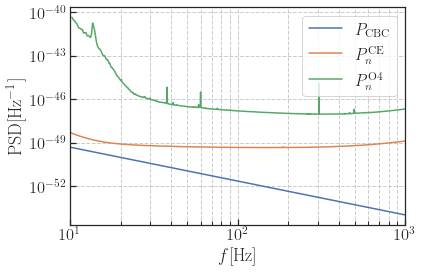

In [12]:
def P_CBC(freqs, Omega, fref):
    H0 = 2.196e-18
    pi = np.pi
    Omega_f = Omega * (freqs/fref)**(2./3)
    return 3*H0**2/(10*pi**2*freqs**3) * Omega_f

CE_PSD = np.genfromtxt("./Data/CE_40_PSD.txt")
O4_PSD = np.genfromtxt("./Data/O4_mock_PSD.txt")

freqs = np.linspace(10, 1000, 5000)
Omega = 6e-10
fref = 25
plt.loglog(freqs, P_CBC(freqs, Omega, fref), label=r"$P_\mathrm{CBC}$")
plt.loglog(CE_PSD[:, 0], CE_PSD[:, 1], label=r"$P_n^\mathrm{CE}$")
plt.loglog(O4_PSD[:, 0], O4_PSD[:, 1]**2, label=r"$P_n^\mathrm{O4}$")
plt.xlim(10, 1000)
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(which='both', direction='in')
plt.legend()
plt.xlabel(r"$f$[Hz]")
plt.ylabel(r"PSD[Hz$^{-1}$]")

# Fig 4 is produced via Powerpoint

# Fig 5

/tmp/ipykernel_2341/3303335498.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.5)


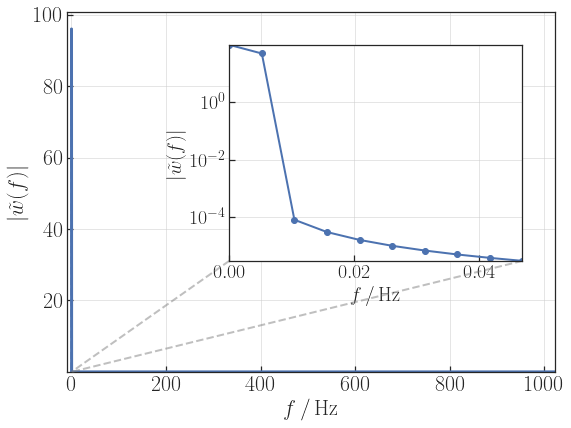

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


data = scipy.signal.windows.hann(192*2048)


fig, ax = plt.subplots(figsize=(8, 6))

f_main = np.fft.rfftfreq(192*2048)*2048
wf_main = np.abs(np.fft.rfft(data))/2048


ax.plot(f_main, wf_main, linewidth=3, color="C0")
ax.set_xlabel(r"$f\,/\,\mathrm{Hz}$", fontsize=22)
ax.set_ylabel(r"$|\tilde{w}(f)|$", fontsize=22)
ax.tick_params(axis='both', labelsize=22)
ax.set_xlim(-10, 1024)
ax.set_ylim(1e-4)
ax_inset = inset_axes(ax, width="60%", height="60%", loc="upper right",
                      borderpad=2)

ax_inset.plot(f_main[:10], wf_main[:10], marker='o', linewidth=2)
ax_inset.set_xlabel(r"$f\,/\,\mathrm{Hz}$", fontsize=20)
ax_inset.set_ylabel(r"$|\tilde{w}(f)|$", fontsize=20)
ax_inset.tick_params(axis='both', labelsize=20)


ax_inset.set_xlim([min(f_main[:10]), max(f_main[:10])])
ax_inset.set_ylim([min(wf_main[:10]), max(wf_main[:10])])
ax_inset.set_yscale("log")
ax.tick_params(direction='in')
ax_inset.tick_params(direction='in')

mark_inset(ax, ax_inset, loc1=3, loc2=4, fc="none", ec="gray", lw=2.0, alpha=0.5, ls="--")

ax.grid(alpha=0.5)
ax_inset.grid(alpha=0.5)

plt.tight_layout(pad=0.5)

# Fig 6

In [17]:
N = 128

num = 0
w = scipy.signal.windows.hann(128)
M = np.arange(2,42,1)
for j in range(N):
    for k in range(N):
        num += w[j]**2*w[k]**2*(np.sinc((j-k)*M/N)/np.sinc((j-k)/N))**2
r = num/np.sum(w**2)**2

num = 0
w = np.ones(128)
M = np.arange(2,42,1)
for j in range(N):
    for k in range(N):
        num += w[j]**2*w[k]**2*(np.sinc((j-k)*M/N)/np.sinc((j-k)/N))**2
r_rect = num/np.sum(w**2)**2

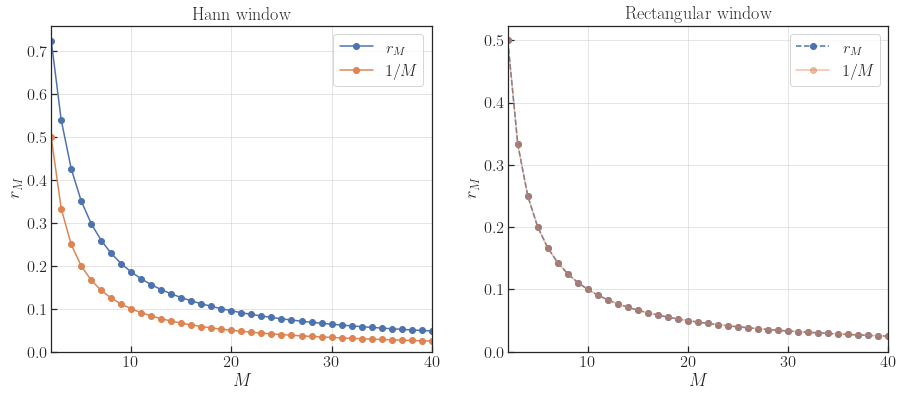

In [18]:
plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.title("Hann window")
plt.plot(M, r, "o-", label=r"$r_M$")
plt.plot(M, 1/M, "o-", label=r"$1/M$")
plt.xlabel(r"$M$")
plt.ylabel(r"$r_M$")
plt.legend()
plt.tick_params(direction='in')
plt.xlim(2,40)
plt.ylim(0)
plt.grid(alpha=0.5)
plt.subplot(122)
plt.title("Rectangular window")
plt.plot(M, r_rect, "o--", label=r"$r_M$")
plt.plot(M, 1/M, "o-", alpha=0.5, label=r"$1/M$")
plt.xlabel(r"$M$")
plt.ylabel(r"$r_M$")
plt.legend()
plt.tick_params(direction='in')
plt.xlim(2,40)
plt.ylim(0)
plt.grid(alpha=0.5)

# Fig 7

Text(0.5, 1.0, 'Rectangular Window')

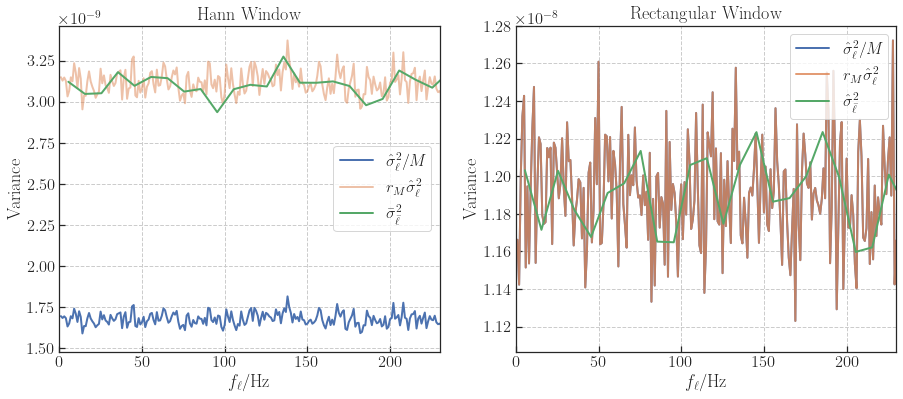

In [19]:
plt.figure(figsize=(15,6))
plt.subplot(121)
C = np.zeros([10000, 1023])
w = scipy.signal.windows.hann(2048)
for i in range(10000):
    d1 = np.random.normal(size=2048)/2048
    d2 = np.random.normal(size=2048)/2048
    d1_f = np.fft.rfft(d1*w)
    d2_f = np.fft.rfft(d2*w)
    C[i] = np.real(d1_f[1:-1] * np.conj(d2_f[1:-1]))

fs = 2048
N = 2048
freq_full = np.fft.rfftfreq(N, d=1/fs)  # freq_full大小为N//2+1，从0到fs/2
freq = freq_full[1:-1]
bins = 10

length = C.shape[1]
new_length = (length // bins) * bins  # 截断到10的倍数

C_truncated = C[:, :new_length]
C_coarse = C_truncated.reshape(10000, new_length//bins, bins).mean(axis=2)

freq_truncated = freq[:new_length]
freq_coarse = freq_truncated.reshape(new_length//bins, bins).mean(axis=1)

Var_f = np.std(C,axis=0)**2
Var_f_coarse = np.std(C_coarse, axis=0)**2
#plt.plot(freq, Var_f, label=r"$\sigma^2(f)$")
plt.plot(freq, Var_f/bins, lw=2, label=r"$\hat{\sigma}^2_\ell/M$")
plt.plot(freq, Var_f*0.18578526362599432, alpha=0.5, lw=2, label=r"$r_M\hat{\sigma}^2_\ell$")
plt.plot(freq_coarse, Var_f_coarse, lw=2, label=r"$\bar{\sigma}^2_{\bar\ell}$")
plt.xlabel(r"$f_\ell$/Hz")
plt.ylabel("Variance")
plt.legend()
plt.xlim(0,230)
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')
plt.title("Hann Window")

plt.subplot(122)
C = np.zeros([10000, 1023])
for i in range(10000):
    d1 = np.random.normal(size=2048)
    d2 = np.random.normal(size=2048)
    d1_f = np.fft.rfft(d1)/2048
    d2_f = np.fft.rfft(d2)/2048
    C[i] = np.real(d1_f[1:-1] * np.conj(d2_f[1:-1]))

fs = 2048
N = 2048
freq_full = np.fft.rfftfreq(N, d=1/fs)  # freq_full大小为N//2+1，从0到fs/2
freq = freq_full[1:-1]
bins = 10

length = C.shape[1]
new_length = (length // bins) * bins  # 截断到10的倍数

C_truncated = C[:, :new_length]
C_coarse = C_truncated.reshape(10000, new_length//bins, bins).mean(axis=2)

freq_truncated = freq[:new_length]
freq_coarse = freq_truncated.reshape(new_length//bins, bins).mean(axis=1)

Var_f = np.std(C,axis=0)**2
Var_f_coarse = np.std(C_coarse, axis=0)**2
#plt.plot(freq, Var_f, label=r"$\sigma^2(f)$")
plt.plot(freq, Var_f/bins, lw=2, label=r"$\hat{\sigma}^2_\ell/M$")
plt.plot(freq, Var_f*0.1, alpha=0.8, lw=2, label=r"$r_M\hat{\sigma}^2_\ell$")
plt.plot(freq_coarse, Var_f_coarse, alpha=1, lw=2, label=r"$\hat{\sigma}^2_{\bar\ell}$")
plt.xlabel(r"$f_\ell$/Hz")
plt.ylabel("Variance")
plt.legend()
plt.xlim(0,230)
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')
plt.title("Rectangular Window")

# Fig 8

(-2.0, 28.0, -0.05, 1.02)

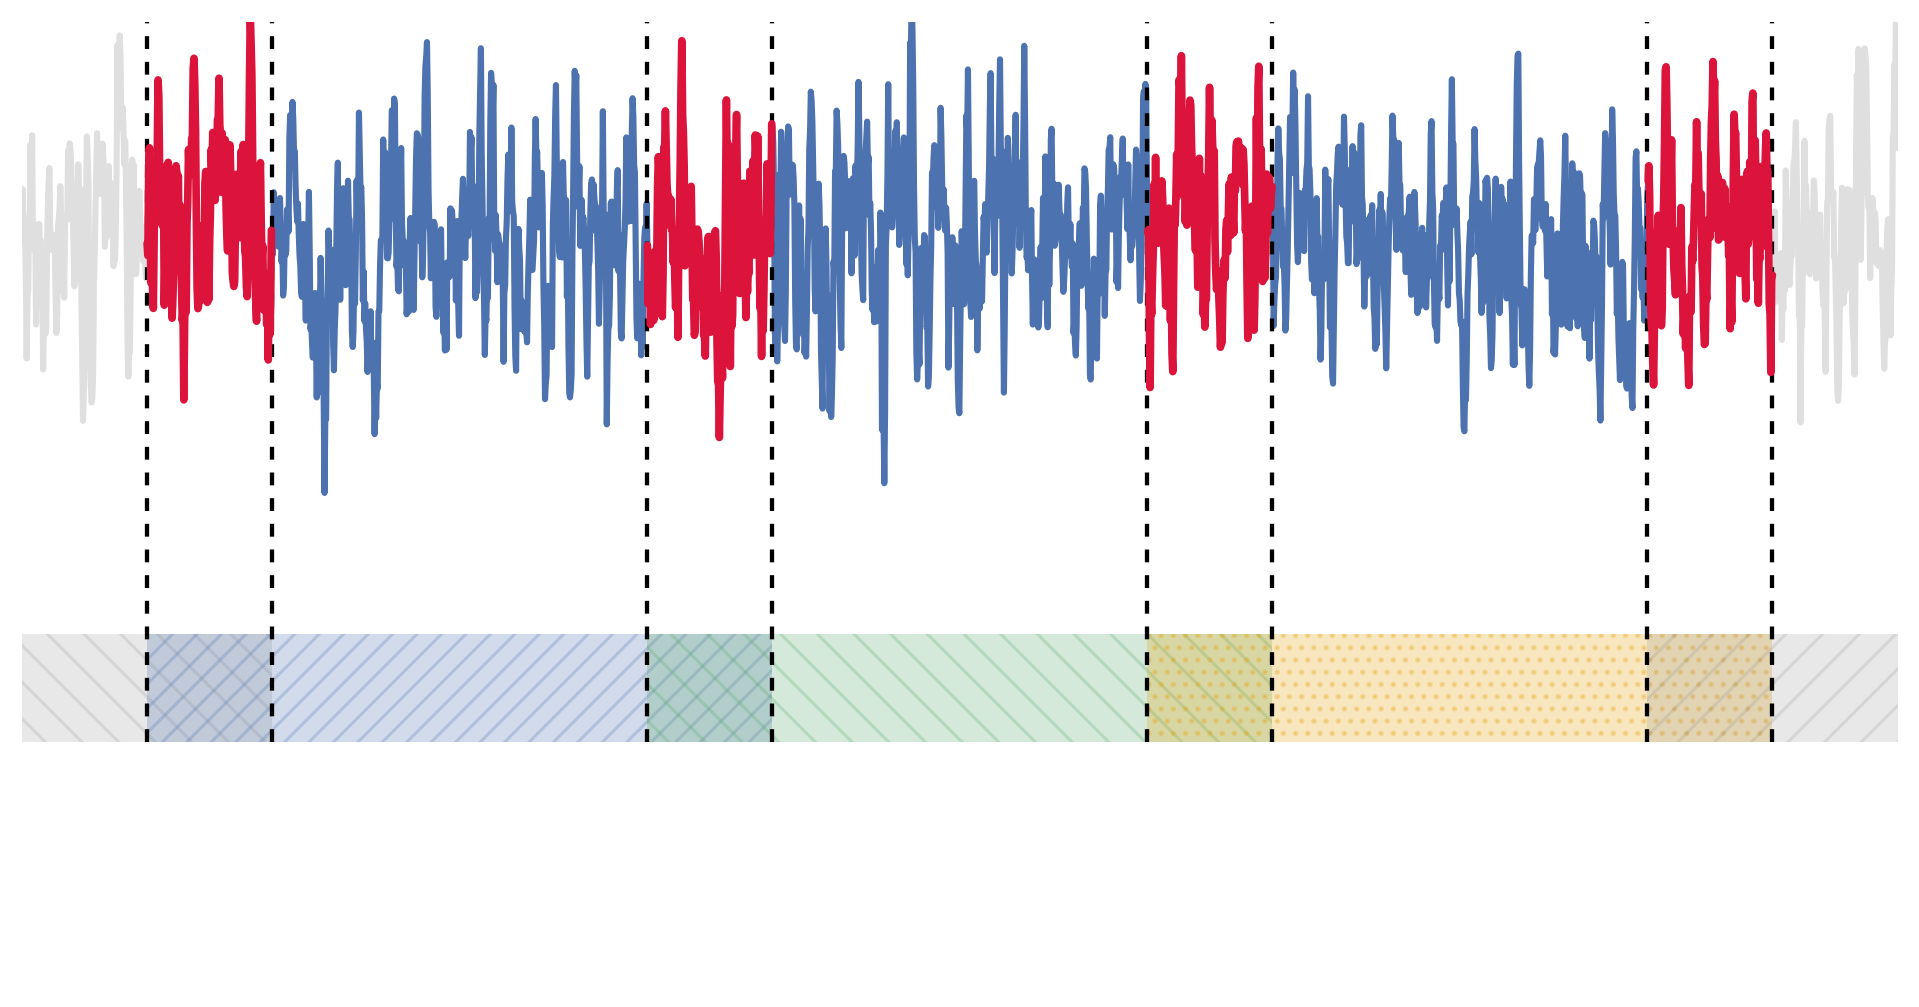

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

N = 10.0
O = 0.2                 # overlap fraction
ON = O * N
core = (1 - 2 * O) * N  # unique middle part of each segment

# Visible segment labels: I-1, I, I+1
# Total shown region consists of:
# ON | core | ON | core | ON | core | ON
x0 = 0.0
b0 = x0
b1 = b0 + ON
b2 = b1 + core
b3 = b2 + ON
b4 = b3 + core
b5 = b4 + ON
b6 = b5 + core
b7 = b6 + ON

extra = 2.0
x_min = b0 - extra
x_max = b7 + extra

rng = np.random.default_rng(4)
x = np.linspace(x_min, x_max, 2400)
y = 0.18 * rng.normal(size=x.size)
kernel = np.ones(5) / 5
y = np.convolve(y, kernel, mode="same")
y_top = 0.78 + y

fig, ax = plt.subplots(figsize=(11, 5.8), dpi=220)

rect_y = 0.22
rect_h = 0.12

blue  = {"color": "#4c72b0", "hatch": "///"}
green = {"color": "#55a868", "hatch": "\\\\"}
orange= {"color": "#e69f00", "hatch": "..."}
grey_left  = {"color": "gray",    "hatch": "\\\\"}
grey_right  = {"color": "gray",    "hatch": "//"}

def add_band(xstart, width, specs, alpha_main=0.25, alpha_grey=0.18, z=1):
    """
    Draw one band region, possibly with multiple hatches overlaid.
    specs: list of spec dictionaries
    """
    for spec in specs:
        alpha = alpha_grey if spec in (grey_left, grey_right) else alpha_main
        ax.add_patch(
            Rectangle(
                (xstart, rect_y),
                width,
                rect_h,
                facecolor=spec["color"],
                edgecolor=spec["color"],
                hatch=spec["hatch"],
                linewidth=0,
                alpha=alpha,
                zorder=z,
            )
        )

# -------------------------
# bottom bands (correct structure)
# -------------------------

# extra grey on left
add_band(x_min, extra, [grey_left], z=0)

# left outside overlap: previous unseen segment + first visible segment
add_band(b0, ON, [grey_left, blue])

# unique part of segment I-1
add_band(b1, core, [blue])

# overlap between I-1 and I
add_band(b2, ON, [blue, green])

# unique part of segment I
add_band(b3, core, [green])

# overlap between I and I+1
add_band(b4, ON, [green, orange])

# unique part of segment I+1
add_band(b5, core, [orange])

# right outside overlap: last visible segment + next unseen segment
add_band(b6, ON, [orange, grey_right])

# extra grey on right
add_band(b7, extra, [grey_right], z=0)

# -------------------------
# time series
# -------------------------

# grey outside data
mask_left_extra = x < b0
mask_right_extra = x > b7
mask_mid = (x >= b0) & (x <= b7)

ax.plot(x[mask_left_extra], y_top[mask_left_extra], color="gray", lw=2, alpha=0.25, zorder=1.5)
ax.plot(x[mask_right_extra], y_top[mask_right_extra], color="gray", lw=2, alpha=0.25, zorder=1.5)

# main visible data
ax.plot(x[mask_mid], y_top[mask_mid], color="#4c72b0", lw=2, zorder=2)

# overlap regions in red
overlap_regions = [
    (b0, b1),
    (b2, b3),
    (b4, b5),
    (b6, b7),
]

for a, b in overlap_regions:
    mask = (x >= a) & (x <= b)
    ax.plot(x[mask], y_top[mask], color="crimson", lw=2.5, zorder=3)

# -------------------------
# dashed vertical boundaries
# -------------------------
boundaries = [b0, b1, b2, b3, b4, b5, b6, b7]
for b in boundaries:
    ax.plot([b, b], [rect_y, 1.02], ls=(0, (3, 3)), color="black", lw=1.4)

ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.05, 1.02)
ax.axis("off")

# Fig 9 & Fig 10

## T=192s

/home/haowen.zhong/.conda/envs/Hierfit/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


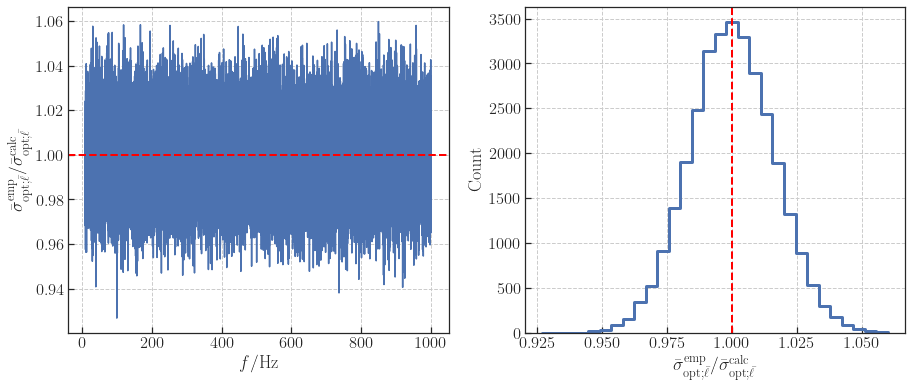

In [24]:
CC_192 = np.load("./Data/Bias_spectra_192.npz")
frequencies = CC_192['frequencies']
bias = CC_192['bias']

plt.figure(figsize=(15,6))
plt.subplot(121)
plt.plot(frequencies, bias)
plt.axhline(np.mean(bias), color="red", ls="--", lw=2)
plt.xlabel(r"$f/$Hz")
plt.ylabel(r"$\bar\sigma^{\mathrm{emp}}_{\mathrm{opt};\bar\ell}/\bar\sigma^\mathrm{calc}_{\mathrm{opt};\bar\ell}$")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')
plt.subplot(122)
sns.histplot(bias.reshape(-1), element="step", bins=30, fill=False, lw=3)
plt.axvline(np.mean(bias), color="red", ls="--", lw=2)
plt.xlabel(r"$\bar\sigma^{\mathrm{emp}}_{\mathrm{opt};\bar\ell}/\bar\sigma^\mathrm{calc}_{\mathrm{opt};\bar\ell}$")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')

/home/haowen.zhong/.conda/envs/Hierfit/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


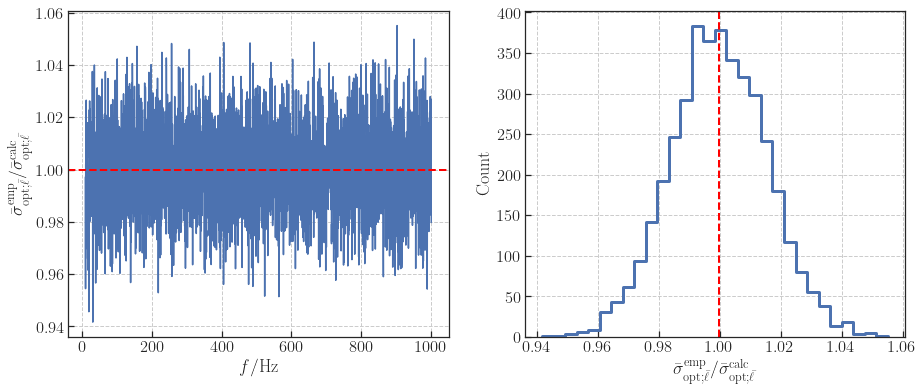

In [26]:
Bias_4 = np.load("./Data/Bias_spectra_4.npz")
frequencies = Bias_4['frequencies']
bias = Bias_4['bias']

plt.figure(figsize=(15,6))
plt.subplot(121)
plt.plot(frequencies, bias)
plt.axhline(np.mean(bias), color="red", ls="--", lw=2)
plt.xlabel(r"$f/$Hz")
plt.ylabel(r"$\bar\sigma^{\mathrm{emp}}_{\mathrm{opt};\bar\ell}/\bar\sigma^\mathrm{calc}_{\mathrm{opt};\bar\ell}$")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')
plt.subplot(122)
sns.histplot(bias.reshape(-1), element="step", bins=30, fill=False, lw=3)
plt.axvline(np.mean(bias), color="red", ls="--", lw=2)
plt.xlabel(r"$\bar\sigma^{\mathrm{emp}}_{\mathrm{opt};\bar\ell}/\bar\sigma^\mathrm{calc}_{\mathrm{opt};\bar\ell}$")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')

# Fig. 11

### Compute $\mathcal{C}[\ell,m]$

In [103]:
O = 0.5
T = 4
Delta_t = 1/2048
N = int(T/Delta_t)
M = 2

result = np.load("./Data/point_estimate_sigma_0-2048_4.npz")
sigma_tf = result['sigma_spectrogram']
sigma_oo = 1/np.sum(sigma_tf[::2, :]**-2, axis=0)
sigma_ee = 1/np.sum(sigma_tf[1::2, :]**-2, axis=0)
sigma_bar_inv = 1/sigma_oo + 1/sigma_ee - 1/2*(sigma_tf[0, :]**-2 + sigma_tf[-1, :]**-2)
w = scipy.signal.get_window("hann", N)
w2 = np.mean(w**2)

w1w2curlybarsquared = 0.12793878383771046
w1w2curlyovlbarsquared = 0.01500853350835192
r_of_M = w1w2curlybarsquared/w2**2
k_l = w1w2curlyovlbarsquared/w1w2curlybarsquared
# Compute w^2
w_sq = np.zeros([2*N])
w_sq[:N] = w*w


# Compute the FFT of w^2
w_sq_tilde = np.fft.fft(w_sq)*Delta_t
w_sq_tilde_abs = np.abs(w_sq_tilde)**2/(T**2*w2**2)


# Compute w^2
w_sq_ovl = np.zeros(2*N)
for i in range(N//2, N):
    w_sq_ovl[i] = w[i] * w[i-N//2] 
    
# Compute the FFT of w^2
w_sq_ovl_tilde = np.fft.fft(w_sq_ovl)*Delta_t
w_sq_ovl_tilde_abs = np.abs(w_sq_ovl_tilde)**2/(T**2*w2**2)

In [104]:
M = 2
l_cg = 10
m_cg = 10
F_cg_0 = 0
F_cg_ovl_0 = 0
for p in range(M*l_cg-M//2, M*l_cg+M//2):
    for q in range(M*m_cg-M//2, M*m_cg+M//2):
        F_cg_0 += w_sq_tilde_abs[p-q] + w_sq_tilde_abs[p+q]
        F_cg_ovl_0 += w_sq_ovl_tilde_abs[p-q] + w_sq_ovl_tilde_abs[p+q]


l_cg = 10
m_cg = 11
F_cg_1 = 0
F_cg_ovl_1 = 0
for p in range(M*l_cg-M//2, M*l_cg+M//2):
    for q in range(M*m_cg-M//2, M*m_cg+M//2):
        F_cg_1 += w_sq_tilde_abs[p-q] + w_sq_tilde_abs[p+q]
        F_cg_ovl_1 += w_sq_ovl_tilde_abs[p-q] + w_sq_ovl_tilde_abs[p+q]

l_cg = 10
m_cg = 12
F_cg_2 = 0
F_cg_ovl_2 = 0
for p in range(M*l_cg-M//2, M*l_cg+M//2):
    for q in range(M*m_cg-M//2, M*m_cg+M//2):
        F_cg_2 += w_sq_tilde_abs[p-q] + w_sq_tilde_abs[p+q]
        F_cg_ovl_2 += w_sq_ovl_tilde_abs[p-q] + w_sq_ovl_tilde_abs[p+q]
        
l_cg = 10
m_cg = 13
F_cg_3 = 0
F_cg_ovl_3 = 0
for p in range(M*l_cg-M//2, M*l_cg+M//2):
    for q in range(M*m_cg-M//2, M*m_cg+M//2):
        F_cg_3 += w_sq_tilde_abs[p-q] + w_sq_tilde_abs[p+q]
        F_cg_ovl_3 += w_sq_ovl_tilde_abs[p-q] + w_sq_ovl_tilde_abs[p+q]

In [105]:
A = 1/sigma_oo*(1-O**2*k_l*sigma_oo*sigma_bar_inv) / (1/sigma_oo+1/sigma_ee-2*O**2*k_l*sigma_bar_inv)
B = 1/sigma_ee*(1-O**2*k_l*sigma_ee*sigma_bar_inv) / (1/sigma_oo+1/sigma_ee-2*O**2*k_l*sigma_bar_inv)


Cov_oo_0 = F_cg_0 * sigma_oo/r_of_M/M**2
Cov_ee_0 = F_cg_0 * sigma_ee/r_of_M/M**2
Cov_oe_0 = F_cg_ovl_0 * sigma_oo*sigma_ee*sigma_bar_inv/r_of_M/M**2


Cov_oo_1 = F_cg_1 * sigma_oo/r_of_M/M**2
Cov_ee_1 = F_cg_1 * sigma_ee/r_of_M/M**2
Cov_oe_1 = F_cg_ovl_1 * sigma_oo*sigma_ee*sigma_bar_inv/r_of_M/M**2

Cov_oo_2 = F_cg_2 * sigma_oo/r_of_M/M**2
Cov_ee_2 = F_cg_2 * sigma_ee/r_of_M/M**2
Cov_oe_2 = F_cg_ovl_2 * sigma_oo*sigma_ee*sigma_bar_inv/r_of_M/M**2

Cov_oo_3 = F_cg_3 * sigma_oo/r_of_M/M**2
Cov_ee_3 = F_cg_3 * sigma_ee/r_of_M/M**2
Cov_oe_3 = F_cg_ovl_3 * sigma_oo*sigma_ee*sigma_bar_inv/r_of_M/M**2

C_0 = A**2*Cov_oo_0 + B**2*Cov_ee_0 + 2*A*B*Cov_oe_0
C_1 = A**2*Cov_oo_1 + B**2*Cov_ee_1 + 2*A*B*Cov_oe_1
C_2 = A**2*Cov_oo_2 + B**2*Cov_ee_2 + 2*A*B*Cov_oe_2
C_3 = A**2*Cov_oo_3 + B**2*Cov_ee_3 + 2*A*B*Cov_oe_3

In [106]:
r1_theory_4 = np.mean(C_1[:]/C_0[:])
r2_theory_4 = np.mean(C_2[:]/C_0[:])
r3_theory_4 = np.mean(C_3[:]/C_0[:])
print("r1_theory= ", r1_theory_4)
print("r2_theory= ", r2_theory_4)
print("r3_theory= ", r3_theory_4)

r1_theory=  0.5233722908319854
r2_theory=  0.06943774343947706
r3_theory=  0.002848871586906449


In [107]:
O = 0.5
T = 192
Delta_t = 1/2048
N = int(T/Delta_t)
M = 12

result = np.load("./Data/point_estimate_sigma_0-2048_192.npz")
sigma_tf = result['sigma_spectrogram']
sigma_oo = 1/np.sum(sigma_tf[::2, :]**-2, axis=0)
sigma_ee = 1/np.sum(sigma_tf[1::2, :]**-2, axis=0)
sigma_bar_inv = 1/sigma_oo + 1/sigma_ee -1/2*(sigma_tf[0, :]**-2 + sigma_tf[-1, :]**-2)

w = scipy.signal.get_window("hann", N)
w2 = np.mean(w**2)
w1w2curlybarsquared = 0.041115231854855105
w1w2curlyovlbarsquared = 0.0066149463588630365
k_l = w1w2curlyovlbarsquared/w1w2curlybarsquared
r_of_M = w1w2curlybarsquared/w2**2

In [108]:
# Compute w^2
w_sq = np.zeros(2*N)
w_sq[:N] = w**2

# Compute the FFT of w^2
w_sq_tilde = np.fft.fft(w_sq)*Delta_t
w_sq_tilde_abs = np.abs(w_sq_tilde)**2/(T**2*w2**2)


# Compute w^2
w_sq_ovl = np.zeros(2*N)
for i in range(N//2, N):
    w_sq_ovl[i] = w[i] * w[i-N//2] 
    
# Compute the FFT of w^2
w_sq_ovl_tilde = np.fft.fft(w_sq_ovl)*Delta_t
w_sq_ovl_tilde_abs = np.abs(w_sq_ovl_tilde)**2/(T**2*w2**2)

In [109]:
M = 12
l_cg = 10
m_cg = 10
F_cg_0 = 0
F_cg_ovl_0 = 0
for p in range(M*l_cg-M//2, M*l_cg+M//2):
    for q in range(M*m_cg-M//2, M*m_cg+M//2):
        F_cg_0 += w_sq_tilde_abs[p-q] + w_sq_tilde_abs[p+q]
        F_cg_ovl_0 += w_sq_ovl_tilde_abs[p-q] + w_sq_ovl_tilde_abs[p+q]


l_cg = 10
m_cg = 11
F_cg_1 = 0
F_cg_ovl_1 = 0
for p in range(M*l_cg-M//2, M*l_cg+M//2):
    for q in range(M*m_cg-M//2, M*m_cg+M//2):
        F_cg_1 += w_sq_tilde_abs[p-q] + w_sq_tilde_abs[p+q]
        F_cg_ovl_1 += w_sq_ovl_tilde_abs[p-q] + w_sq_ovl_tilde_abs[p+q]

l_cg = 10
m_cg = 12
F_cg_2 = 0
F_cg_ovl_2 = 0
for p in range(M*l_cg-M//2, M*l_cg+M//2):
    for q in range(M*m_cg-M//2, M*m_cg+M//2):
        F_cg_2 += w_sq_tilde_abs[p-q] + w_sq_tilde_abs[p+q]
        F_cg_ovl_2 += w_sq_ovl_tilde_abs[p-q] + w_sq_ovl_tilde_abs[p+q]

In [114]:
A = 1/sigma_oo*(1-O**2*k_l*sigma_oo*sigma_bar_inv) / (1/sigma_oo+1/sigma_ee-2*O**2*k_l*sigma_bar_inv)
B = 1/sigma_ee*(1-O**2*k_l*sigma_ee*sigma_bar_inv) / (1/sigma_oo+1/sigma_ee-2*O**2*k_l*sigma_bar_inv)


Cov_oo_0 = F_cg_0 * sigma_oo/r_of_M/M**2
Cov_ee_0 = F_cg_0 * sigma_ee/r_of_M/M**2
Cov_oe_0 = F_cg_ovl_0 * sigma_oo*sigma_ee*sigma_bar_inv/r_of_M/M**2


Cov_oo_1 = F_cg_1 * sigma_oo/r_of_M/M**2
Cov_ee_1 = F_cg_1 * sigma_ee/r_of_M/M**2
Cov_oe_1 = F_cg_ovl_1 * sigma_oo*sigma_ee*sigma_bar_inv/r_of_M/M**2

Cov_oo_2 = F_cg_2 * sigma_oo/r_of_M/M**2
Cov_ee_2 = F_cg_2 * sigma_ee/r_of_M/M**2
Cov_oe_2 = F_cg_ovl_2 * sigma_oo*sigma_ee*sigma_bar_inv/r_of_M/M**2

C_0 = A**2*Cov_oo_0 + B**2*Cov_ee_0 + 2*A*B*Cov_oe_0
C_1 = A**2*Cov_oo_1 + B**2*Cov_ee_1 + 2*A*B*Cov_oe_1
C_2 = A**2*Cov_oo_2 + B**2*Cov_ee_2 + 2*A*B*Cov_oe_2

In [115]:
r1_theory_192 = np.mean(C_1[:]/C_0[:])
r2_theory_192 = np.mean(C_2[:]/C_0[:])
print("r1_theory= ", r1_theory_192)
print("r2_theory= ", r2_theory_192)

r1_theory=  0.05654238881410887
r2_theory=  5.679937893473935e-07


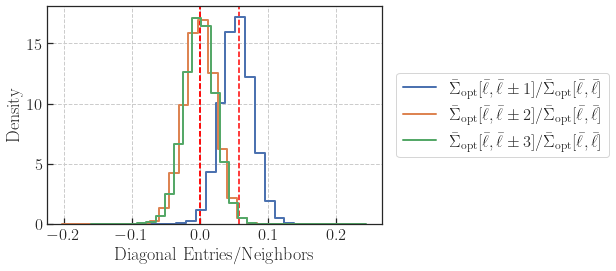

In [116]:
ratio_192 = np.load("./Data/Cov_ratio_192.npz")
r_1 = ratio_192['r_1']
r_2 = ratio_192['r_2']
r_3 = ratio_192['r_3']

plt.axvline(r1_theory_192, color="red", ls="--")
plt.axvline(r2_theory_192, color="red", ls="--")
plt.axvline(0, color="red", ls="--")
sns.histplot(r_1[(r_1<=0.25) * (r_1>=-0.25)], element="step",  bins=30, lw=2, stat='density', fill=False, label=r"$\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}\pm1]/\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}]$")
sns.histplot(r_2[(r_2<=0.25) * (r_2>=-0.25)],  bins=30, lw=2, element="step", stat='density',fill=False, label=r"$\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}\pm2]/\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}]$")
sns.histplot(r_3[(r_3<=0.25) * (r_3>=-0.25)], element="step", fill=False,  bins=30, lw=2, stat='density', label=r"$\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}\pm3]/\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}]$")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.xlabel("ratio")
plt.xlabel("Diagonal Entries/Neighbors")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')

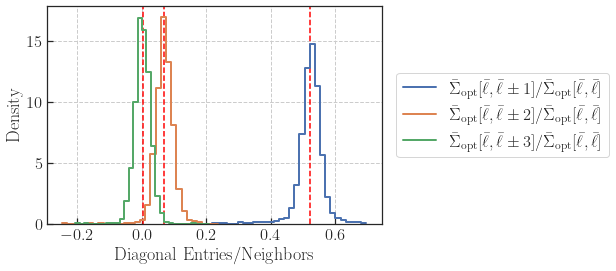

In [117]:
ratio_4 = np.load("./Data/Cov_ratio_4.npz")
r_1 = ratio_4['r_1']
r_2 = ratio_4['r_2']
r_3 = ratio_4['r_3']

plt.axvline(r1_theory_4, color="red", ls="--")
plt.axvline(r2_theory_4, color="red", ls="--")
plt.axvline(r3_theory_4, color="red", ls="--")
sns.histplot(r_1[(r_1<=0.7) * (r_1>=0.2)], element="step",  bins=30, lw=2, stat='density', fill=False, label=r"$\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}\pm1]/\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}]$")
sns.histplot(r_2[(r_2<=0.25) * (r_2>=-0.25)],  bins=30, lw=2, element="step", stat='density',fill=False, label=r"$\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}\pm2]/\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}]$")
sns.histplot(r_3[(r_3<=0.25) * (r_3>=-0.25)], element="step", fill=False,  bins=30, lw=2, stat='density', label=r"$\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}\pm3]/\bar{\Sigma}_\mathrm{opt}[\bar{\ell},\bar{\ell}]$")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.xlabel("Diagonal Entries/Neighbors")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')

# Fig 12.

In [34]:
modified_192s = np.load("./Data/Noise_192s_modified_pygwb.npz")
original_192s = np.load("./Data/Noise_192s_original_pygwb.npz")
modified_4s = np.load("./Data/Noise_4s_modified_pygwb.npz")
original_4s = np.load("./Data/Noise_4s_original_pygwb.npz")

Text(0.5, 1.0, '$T=192~\\mathrm{s},~\\delta f=1/32~\\mathrm{Hz}$')

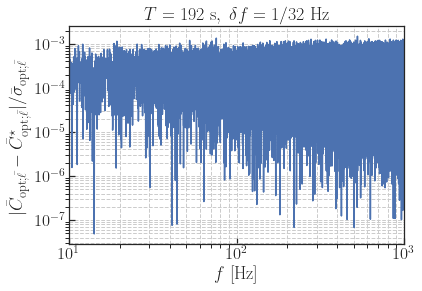

In [35]:
diff = np.real(modified_192s['point_estimate_spectrum']) - np.real(original_192s['point_estimate_spectrum']) 
rel_diff = diff/np.real(original_192s['point_estimate_spectrum']) 
rel_diff_sigma = diff/np.real(modified_192s['sigma_spectrum'])
plt.loglog(modified_192s['frequencies'],np.abs(rel_diff_sigma), color="C0", alpha=1)
plt.xlim(10,1000)
plt.xlabel(r"$f~$[Hz]")
plt.ylabel(r"$|\bar{C}_{\mathrm{opt};\bar\ell}-\bar{C}^\star_{\mathrm{opt};\bar\ell}|/\bar{\sigma}_{\mathrm{opt};\bar\ell}$")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')
plt.title(r"$T=192~\mathrm{s},~\delta f=1/32~\mathrm{Hz}$")

Text(0.5, 1.0, '$T=4~\\mathrm{s},~\\delta f=1/4~\\mathrm{Hz}$')

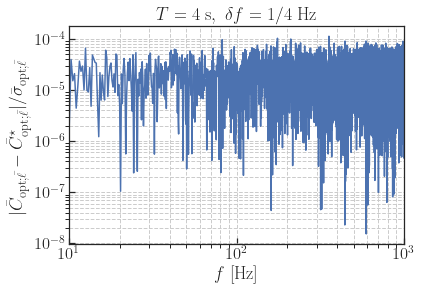

In [36]:
diff = np.real(modified_4s['point_estimate_spectrum']) - np.real(original_4s['point_estimate_spectrum']) 
rel_diff = diff/np.real(original_4s['point_estimate_spectrum']) 
rel_diff_sigma = diff/np.real(modified_4s['sigma_spectrum'])
plt.loglog(modified_4s['frequencies'],np.abs(rel_diff_sigma), color="C0", alpha=1)
plt.xlim(10,1000)
plt.xlabel(r"$f~$[Hz]")
plt.ylabel(r"$|\bar{C}_{\mathrm{opt};\bar\ell}-\bar{C}^\star_{\mathrm{opt};\bar\ell}|/\bar{\sigma}_{\mathrm{opt};\bar\ell}$")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')
plt.title(r"$T=4~\mathrm{s},~\delta f=1/4~\mathrm{Hz}$")

# Fig. 13

In [118]:
r_M_naive = 0
N = 20000
M = 12

w = scipy.signal.windows.hann(N)
w_zp = np.zeros(2 * N)
w_zp[:N] = w

a = w_zp[:N]**2

d = np.arange(-(N - 1), N)
kernel = (np.sinc(d * M / (2 * N))**2) / (np.sinc(d / (2 * N))**2)


corr = fftconvolve(a, a[::-1], mode='full')

num = np.dot(corr, kernel)

denom = np.sum(w_zp**2)**2
r_M_naive = num / denom

ratio = np.sqrt(M * r_M_naive * np.mean(w_zp**2)**2 / np.mean(w_zp**4))
W_K = np.mean(w_zp**4) / ((1 / (2 * N))**2 * num)

print(ratio, np.sqrt(M / W_K))
_, w4, _, w4ovl = window_factors(N)
k_nb = 0.0066149463588630365/0.041115231854855105
k_bb = w4ovl/w4
k_nb, k_bb, np.sqrt((1-k_bb)/(1-0.5 * k_nb) * M/W_K)

0.9498641420706406 0.9498641420706406


(0.16088797412635553, 0.08568381222992667, 0.9471540121744786)

Text(0, 0.5, '$\\sqrt{\\bar{\\Sigma}_{\\mathrm{opt};\\bar{\\ell}\\bar{\\ell}}}/\\bar{\\sigma}^\\star_{\\mathrm{opt};\\bar{\\ell}}$')

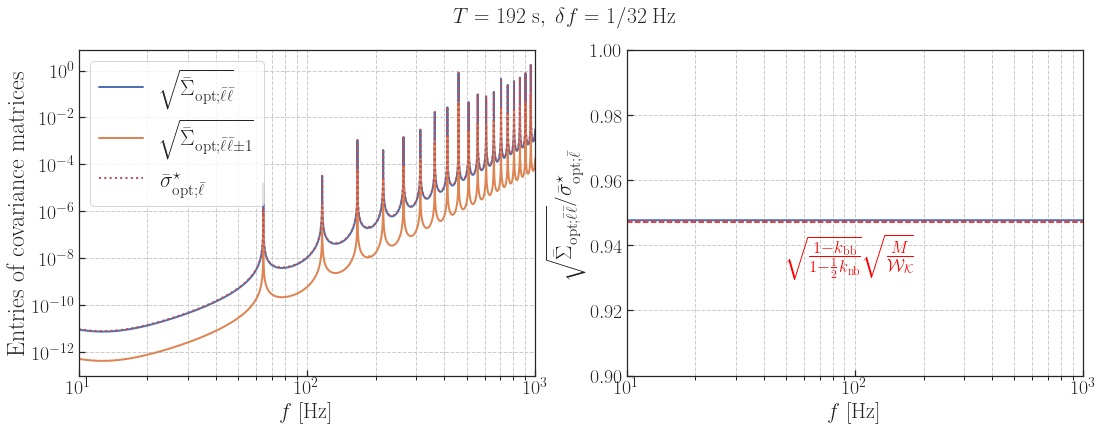

In [119]:
plt.figure(figsize=(18, 6))
plt.suptitle(r"$T=192~\mathrm{s},~\delta f=1/32~\mathrm{Hz}$")
plt.subplot(121)
plt.loglog(modified_192s['frequencies'], modified_192s['sigma_spectrum'], color="C0", lw=2, label=r"$\sqrt{\bar{\Sigma}_{\mathrm{opt};\bar{\ell}\bar{\ell}}}$")
plt.loglog(modified_192s['frequencies'], modified_192s['sigma_spectrum']*r1_theory_192, color="C1", lw=2, label=r"$\sqrt{\bar{\Sigma}_{\mathrm{opt};\bar{\ell}\bar{\ell}\pm1}}$")
plt.loglog(modified_192s['frequencies'], original_192s['sigma_spectrum'], lw=2, color="C3", ls=":", label=r"$\bar{\sigma}^\star_{\mathrm{opt};\bar{\ell}}$")
plt.legend(fontsize=22)
plt.xlim(10,1000)
plt.xlabel(r"$f~$[Hz]", fontsize=22)
plt.ylabel(r"Entries of covariance matrices", fontsize=24)
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in',labelsize=20)
plt.subplot(122)
plt.semilogx(modified_192s['frequencies'], modified_192s['sigma_spectrum']/original_192s['sigma_spectrum'], lw=2, label=r"$\bar{\Sigma}_{\mathrm{opt};\bar{\ell}\bar{\ell}}$")
plt.axhline(np.sqrt((1-k_bb)/(1-0.5 * k_nb) * M/W_K), color="red", ls="--")
plt.text(50, 0.935, r"$\sqrt{\frac{1-k_{\rm{bb}}}{1-\frac{1}{2}k_{\rm{nb}}}}\sqrt{\frac{M}{\mathcal W_{\mathcal{K}}}}$", color="red", fontsize=24)
plt.xlim(10,1000)
plt.ylim(0.9, 1.0)
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in', labelsize=20)
plt.xlabel(r"$f~$[Hz]", fontsize=22)
plt.ylabel(r"$\sqrt{\bar{\Sigma}_{\mathrm{opt};\bar{\ell}\bar{\ell}}}/\bar{\sigma}^\star_{\mathrm{opt};\bar{\ell}}$", fontsize=22)

In [121]:
r_M_naive = 0
N = 20000
M = 2

w = scipy.signal.windows.hann(N)
w_zp = np.zeros(2 * N)
w_zp[:N] = w


a = w_zp[:N]**2

d = np.arange(-(N - 1), N)
kernel = (np.sinc(d * M / (2 * N))**2) / (np.sinc(d / (2 * N))**2)


corr = fftconvolve(a, a[::-1], mode='full')

num = np.dot(corr, kernel)

denom = np.sum(w_zp**2)**2
r_M_naive = num / denom

ratio = np.sqrt(M * r_M_naive * np.mean(w_zp**2)**2 / np.mean(w_zp**4))
W_K = np.mean(w_zp**4) / ((1 / (2 * N))**2 * num)

print(ratio, np.sqrt(M / W_K))
_, w4, _, w4ovl = window_factors(N)
k_nb = 0.01500853350835192/0.12793878383771046
k_bb = w4ovl/w4
k_nb, k_bb, np.sqrt((1-k_bb)/(1-0.5 * k_nb) * M/W_K)

0.6840491228279544 0.6840491228279545


(0.11731027182023358, 0.08568381222992667, 0.6741571051674193)

Text(0, 0.5, '$\\sqrt{\\bar{\\Sigma}_{\\mathrm{opt};\\bar{\\ell}\\bar{\\ell}}}/\\bar{\\sigma}^\\star_{\\mathrm{opt};\\bar{\\ell}}$')

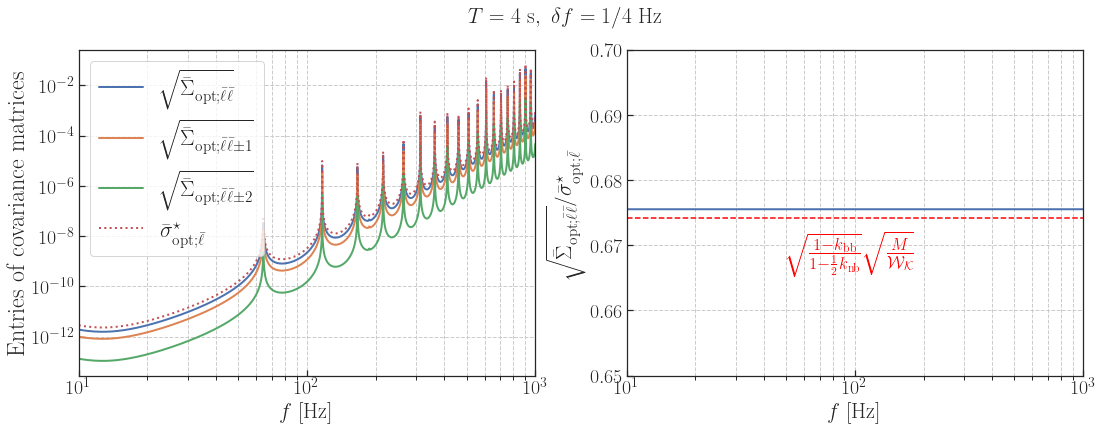

In [122]:
plt.figure(figsize=(18, 6))
plt.suptitle(r"$T=4~\mathrm{s},~\delta f=1/4~\mathrm{Hz}$")
plt.subplot(121)
plt.loglog(modified_4s['frequencies'], modified_4s['sigma_spectrum'], lw=2, label=r"$\sqrt{\bar{\Sigma}_{\mathrm{opt};\bar{\ell}\bar{\ell}}}$")
plt.loglog(modified_4s['frequencies'], modified_4s['sigma_spectrum']*r_1_4s, lw=2, label=r"$\sqrt{\bar{\Sigma}_{\mathrm{opt};\bar{\ell}\bar{\ell}\pm1}}$")
plt.loglog(modified_4s['frequencies'], modified_4s['sigma_spectrum']*r_2_4s, lw=2, label=r"$\sqrt{\bar{\Sigma}_{\mathrm{opt};\bar{\ell}\bar{\ell}\pm2}}$")
plt.loglog(modified_4s['frequencies'], original_4s['sigma_spectrum'], lw=2, ls=":", label=r"$\bar{\sigma}^\star_{\mathrm{opt};\bar{\ell}}$")
plt.legend(fontsize=22)
plt.xlim(10,1000)
plt.xlabel(r"$f~$[Hz]", fontsize=22)
plt.ylabel(r"Entries of covariance matrices", fontsize=24)
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in',labelsize=20)
plt.subplot(122)
plt.semilogx(modified_4s['frequencies'], modified_4s['sigma_spectrum']/original_4s['sigma_spectrum'], lw=2)
plt.axhline(np.sqrt((1-k_bb)/(1-0.5 * k_nb) * M/W_K), color="red", ls="--")
plt.text(50, 0.668, r"$\sqrt{\frac{1-k_{\rm{bb}}}{1-\frac{1}{2}k_{\rm{nb}}}}\sqrt{\frac{M}{\mathcal W_{\mathcal{K}}}}$", color="red", fontsize=24)
plt.xlim(10,1000)
plt.ylim(0.65, 0.7)
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in', labelsize=20)
plt.xlabel(r"$f~$[Hz]", fontsize=22)
plt.ylabel(r"$\sqrt{\bar{\Sigma}_{\mathrm{opt};\bar{\ell}\bar{\ell}}}/\bar{\sigma}^\star_{\mathrm{opt};\bar{\ell}}$", fontsize=22)

# Fig. 14

In [45]:
__all__ = ['Bounded_2d_kde', 'Bounded_1d_kde', 'kdeplot']

import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss
import seaborn as sns
import pandas as pd
from pesummary.core.plots.bounded_1d_kde import bounded_1d_kde
from pesummary.core.plots.bounded_2d_kde import Bounded_2d_kde

class Bounded_1d_kde(ss.gaussian_kde):
    """ Represents a one-dimensional Gaussian kernel density estimator
    for a probability distribution function that exists on a bounded
    domain.

    Authorship: Ben Farr, LIGO
    """

    def __init__(self, pts, x_min=None, x_max=None, *args, **kwargs):
        """Initialize with the given bounds.  Either ``low`` or
        ``high`` may be ``None`` if the bounds are one-sided.  Extra
        parameters are passed to :class:`gaussian_kde`.

        :param x_min: The lower x domain boundary.

        :param x_max: The upper x domain boundary.
        """
        pts = np.atleast_1d(pts)

        assert pts.ndim == 1, 'Bounded_1d_kde can only be one-dimensional'

        super(Bounded_1d_kde, self).__init__(pts.T, *args, **kwargs)

        self._x_min = x_min
        self._x_max = x_max

    @property
    def x_min(self):
        """The lower bound of the x domain."""
        return self._x_min

    @property
    def x_max(self):
        """The upper bound of the x domain."""
        return self._x_max

    def evaluate(self, pts):
        """Return an estimate of the density evaluated at the given
        points."""
        pts = np.atleast_1d(pts)
        assert pts.ndim == 1, 'points must be one-dimensional'

        x = pts.T
        pdf = super(Bounded_1d_kde, self).evaluate(pts.T)
        if self.x_min is not None:
            pdf += super(Bounded_1d_kde, self).evaluate(2*self.x_min - x)

        if self.x_max is not None:
            pdf += super(Bounded_1d_kde, self).evaluate(2*self.x_max - x)

        return pdf

    def __call__(self, pts):
        pts = np.atleast_1d(pts)
        out_of_bounds = np.zeros(pts.shape[0], dtype='bool')

        if self.x_min is not None:
            out_of_bounds[pts < self.x_min] = True
        if self.x_max is not None:
            out_of_bounds[pts > self.x_max] = True

        results = self.evaluate(pts)
        results[out_of_bounds] = 0.
        return results


# The following routine, Bounded_2d_kde, was copied from
# https://git.ligo.org/publications/gw190412/gw190412-discovery/-/blob/851f91431b7c36e7ea66fa47e8516f2aef9d7daf/scripts/bounded_2d_kde.py
class Bounded_2d_kde(ss.gaussian_kde):
    r"""Represents a two-dimensional Gaussian kernel density estimator
    for a probability distribution function that exists on a bounded
    domain."""

    def __init__(self, pts, x_min=None, x_max=None, y_min=None, y_max=None,
                 *args, **kwargs):
        """Initialize with the given bounds.  Either ``low`` or
        ``high`` may be ``None`` if the bounds are one-sided.  Extra
        parameters are passed to :class:`gaussian_kde`.

        :param x_min: The lower x domain boundary.

        :param x_max: The upper x domain boundary.

        :param y_min: The lower y domain boundary.

        :param y_max: The upper y domain boundary.
        """
        pts = np.atleast_2d(pts)

        assert pts.ndim == 2, 'Bounded_kde can only be two-dimensional'

        super(Bounded_2d_kde, self).__init__(pts.T, *args, **kwargs)

        self._x_min = x_min
        self._x_max = x_max
        self._y_min = y_min
        self._y_max = y_max

    @property
    def x_min(self):
        """The lower bound of the x domain."""
        return self._x_min

    @property
    def x_max(self):
        """The upper bound of the x domain."""
        return self._x_max

    @property
    def y_min(self):
        """The lower bound of the y domain."""
        return self._y_min

    @property
    def y_max(self):
        """The upper bound of the y domain."""
        return self._y_max

    def evaluate(self, pts):
        """Return an estimate of the density evaluated at the given
        points."""
        pts = np.atleast_2d(pts)
        assert pts.ndim == 2, 'points must be two-dimensional'

        x, y = pts.T
        pdf = super(Bounded_2d_kde, self).evaluate(pts.T)
        if self.x_min is not None:
            pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_min - x, y])
        if self.x_max is not None:
            pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_max - x, y])
        if self.y_min is not None:
            pdf += super(Bounded_2d_kde, self).evaluate([x, 2*self.y_min - y])
        if self.y_max is not None:
            pdf += super(Bounded_2d_kde, self).evaluate([x, 2*self.y_max - y])
        if self.x_min is not None:
            if self.y_min is not None:
                pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_min - x,
                                                             2*self.y_min - y])
            if self.y_max is not None:
                pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_min - x,
                                                             2*self.y_max - y])
        if self.x_max is not None:
            if self.y_min is not None:
                pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_max - x,
                                                             2*self.y_min - y])
            if self.y_max is not None:
                pdf += super(Bounded_2d_kde, self).evaluate([2*self.x_max - x,
                                                             2*self.y_max - y])
        return pdf

    def __call__(self, pts):
        pts = np.atleast_2d(pts)
        out_of_bounds = np.zeros(pts.shape[0], dtype='bool')

        if self.x_min is not None:
            out_of_bounds[pts[:, 0] < self.x_min] = True
        if self.x_max is not None:
            out_of_bounds[pts[:, 0] > self.x_max] = True
        if self.y_min is not None:
            out_of_bounds[pts[:, 1] < self.y_min] = True
        if self.y_max is not None:
            out_of_bounds[pts[:, 1] > self.y_max] = True

        results = self.evaluate(pts)
        results[out_of_bounds] = 0.
        return results


# ############################################################################
# PLOTTING

def kdeplot_2d_clevels(xs, ys, levels=10, fill=False, n_grid=128, **kws):
    """ Plot contours at specified credible levels.

    Arguments
    ---------
    xs: array
        samples of the first variable.
    ys: array
        samples of the second variable, drawn jointly with `xs`.
    levels: float, array
        if float, interpreted as number of credible levels to be equally 
        spaced between (0, 1); if array, interpreted as list of credible
        levels.
    x_min: float
        lower bound for abscissa passed to Bounded_2d_kde (optional).
    xigh: float
        upper bound for abscissa passed to Bounded_2d_kde (optional).
    y_min: float
        lower bound for ordinate passed to Bounded_2d_kde (optional).
    y_max: float
        upper bound for ordinate passed to Bounded_2d_kde (optional).
    ax: Axes
        matplotlib axes on which to plot (optional).
    kwargs:
        additional arguments passed to plt.contour().
    """
    try:
        xs = xs.values.astype(float)
        ys = ys.values.astype(float)
    except AttributeError:
        pass

    if np.all(~np.isfinite(xs)) or np.all(~np.isfinite(ys)):
        return None
    
    # construct credible levels
    try:
        len(levels)
        f = 1 - np.array(levels)
    except TypeError:
        f = np.linspace(0, 1, levels+1, endpoint=True)[1:-1]
    if fill:
        # f = np.concatenate([f, [1]])
        kws['extend'] = 'max'
    
    # estimate bounded KDE from samples
    if kws.get('auto_bound', False):
        kws['x_min'] = min(xs)
        kws['x_max'] = max(xs)
        kws['y_min'] = min(ys)
        kws['y_max'] = max(ys)
    ks = ['x_min', 'x_max', 'y_min', 'y_max', 'bw_method', 'weights']
    kde_kws = {k: kws.pop(k, None) for k in ks}
    k = Bounded_2d_kde(np.column_stack((xs, ys)), **kde_kws)
    
    # evaluate KDE on all points
    p = k(np.column_stack((xs, ys)))
    
    # the levels passed to the contour function have to be the
    # values of the KDE at corresponding to the quantiles
    # first get the order of the samples sorted by KDE value
    # then find the values that correspond to the thresholds
    i = np.argsort(p)
    l = np.array([p[i[min(int(np.round(ff*len(p))), len(i)-1)]] for ff in f])
    
    # construct grid of x and y values based on the
    # range of the samples
    x_hi, x_lo = np.percentile(xs, 99), np.percentile(xs, 1)
    y_hi, y_lo = np.percentile(ys, 99), np.percentile(ys, 1)
    
    Dx = x_hi - x_lo
    Dy = y_hi - y_lo

    x = np.linspace(x_lo-0.1*Dx, x_hi+0.1*Dx, n_grid)
    y = np.linspace(y_lo-0.1*Dy, y_hi+0.1*Dy, n_grid)

    # construct grids and evaluate KDE
    XS, YS = np.meshgrid(x, y, indexing='ij')
    ZS = k(np.column_stack((XS.flatten(), YS.flatten()))).reshape(XS.shape)

    ax = kws.pop('ax', plt.gca())
    p = kws.get('cmap', kws.pop('palette', None))
    if p is not None:
        kws['colors'] = None
        kws['cmap'] = p
    else:
        kws['colors'] = kws.get('colors', 
                                [kws.pop('color', kws.pop('c', None)),])
    if fill:
        ax.contourf(XS, YS, ZS, levels=l, **kws)
    else:
        ax.contour(XS, YS, ZS, levels=l, **kws)


def kdeplot(x, y=None, **kws):
    
    if np.all(~np.isfinite(x)):
        return None

    if 'hue' in kws:
        hues = kws.pop('hue')
        hues_unique = sorted(hues.unique())
        n_hues = len(hues_unique)
        
        if 'palette' in kws:
            palette = sns.color_palette(kws.pop('palette'), n_colors=n_hues)
        else:
            # attempt to use seaborn's logic for determining the color palette
            # (this will fail if seaborn changes it's internal API)
            try:
                from seaborn.distributions import _DistributionPlotter
                df = pd.DataFrame(dict(x=x, y=y, hue=hues))
                if y is None:
                    df = df.drop(columns='y')
                    v = dict(x='x', hue='hue')
                else:
                    v = dict(x='x', y='y', hue='hue')
                dp = _DistributionPlotter(data=df, variables=v)
                palette = [dp._hue_map(l) for l in dp._hue_map.levels]
            except Exception:
                if pd.api.types.is_numeric_dtype(hues_unique):
                    # Numeric: Use a sequential palette
                    palette = sns.color_palette("ch:", n_colors=n_hues)
                else:
                    # Categorical: Use a qualitative palette
                    palette = sns.color_palette("deep", n_colors=n_hues)

        for hue, color in zip(hues_unique, palette):
            xs_hue = x[hues == hue]
            if y is None:
                ys_hue = None
            else:
                ys_hue = y[hues == hue]
            kdeplot(xs_hue, ys_hue, **kws, color=color)
            plt.plot([], [], c=color, label=hue)
        plt.legend();
        return
    
    if y is not None:
        return kdeplot_2d_clevels(x, y, **kws)
    
    if kws.pop('auto_bound', False):
        kws['x_min'] = min(x)
        kws['x_max'] = max(x)
    kde_kws = {k: kws.pop(k, None) for k in 
               ['x_min', 'x_max', 'bw_method', 'weights']}
    k = Bounded_1d_kde(x, **kde_kws)
    
    x_hi, x_lo = np.percentile(x, 99), np.percentile(x, 1)
    
    Dx = x_hi - x_lo
    xgrid = np.linspace(x_lo-0.1*Dx, x_hi+0.1*Dx, kws.pop('n_grid', 128))
    ygrid = k(xgrid)
    ax = kws.pop('ax', plt.gca())
    ax.plot(xgrid, ygrid, **kws)
    
    if kws.get('fill', False):
        alpha = kws.get('alpha', 0.5)
        ax.fill_between(xgrid, 0, ygrid, alpha=alpha, **kws)

In [46]:
Data = np.load("./Data/Post_4.npz")
Omega_full = Data['Omega_full']
alpha_full = Data['alpha_full']
Omega_original = Data['Omega_original']
alpha_original = Data['alpha_original']

/tmp/ipykernel_2341/3105725766.py:273: UserWarning: The following kwargs were not used by contour: 'auto_bound', 'linewidth', 'label'
  ax.contour(XS, YS, ZS, levels=l, **kws)


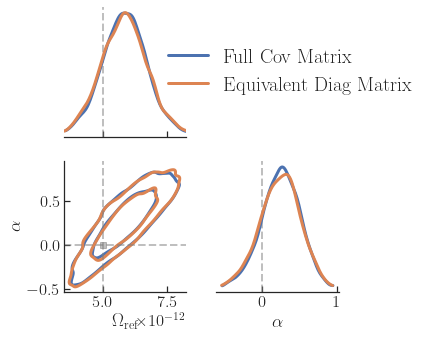

In [49]:
df1 = pd.DataFrame({r'$\Omega_\mathrm{ref}$': Omega_full, r'$\alpha$': alpha_full, 'dataset': r'full'})
df2 = pd.DataFrame({r'$\Omega_\mathrm{ref}$': Omega_original, r'$\alpha$': alpha_original, 'dataset': r'original'})
# Concatenate the datasets
df = pd.concat([df1, df2])

cls = [0.95, 0.68]
p1 = sns.color_palette("light:C0", as_cmap=True)
p2 = sns.color_palette("light:C1", as_cmap=True)
hue_kws = dict(
    levels=[cls, cls],
    fill=[False, False],
    color=['#4c72b0', '#dd8452'],
    linestyles=['-', '-'],
    linewidths=[3, 3],
    alpha=[1, 1],
    zorder=[1, 1]
)
cornerresult = sns.PairGrid(df, vars=[r"$\Omega_\mathrm{ref}$", r"$\alpha$"],
             corner=True,
             palette=['C0', 'C1'],
             hue_kws=hue_kws,
             hue='dataset',
             diag_sharey=False)
cornerresult.map_diag(kdeplot, auto_bound=True, linewidth=3)
cornerresult.map_lower(kdeplot, auto_bound=True, linewidth=3)


diag_index = [0, 3]
joint_index = [2]
diag_truths = [5e-12, 0] 
joint_truths_h = [0]
joint_truths_v = [5e-12]
for i, ax in enumerate(cornerresult.axes.ravel()[joint_index]):
    ax.axvline(joint_truths_v[i], ls='--', linewidth=2, c='gray', alpha=0.5)
    ax.axhline(joint_truths_h[i], ls='--', linewidth=2, c='gray', alpha=0.5)
    ax.plot(joint_truths_v[i], joint_truths_h[i], marker="s", color="gray", alpha=0.5)
    ax.tick_params(direction='in')
for i, ax in enumerate(cornerresult.axes.ravel()[diag_index]):
    ax.axvline(diag_truths[i], ls='--', linewidth=2, c='gray', alpha=0.5)
    ax.tick_params(direction='in')
a = Line2D([0,1],[0,1], linestyle='-', linewidth=3, color='#4c72b0')
b = Line2D([0,1],[0,1], linestyle='-', linewidth=3, color='#dd8452')
#f = Line2D([0,1],[0,1], linestyle='-', linewidth=3, color='#937860')
plt.legend([a, b], [  r"Full Cov Matrix",
                      r"Equivalent Diag Matrix"],
          framealpha=0, edgecolor='w', loc='best',bbox_to_anchor=(3, 2), fontsize=20)

In [51]:
Data = np.load("./Data/Post_192.npz")
Omega_full = Data['Omega_full']
alpha_full = Data['alpha_full']
Omega_original = Data['Omega_original']
alpha_original = Data['alpha_original']

/tmp/ipykernel_2341/3105725766.py:273: UserWarning: The following kwargs were not used by contour: 'auto_bound', 'linewidth', 'label'
  ax.contour(XS, YS, ZS, levels=l, **kws)


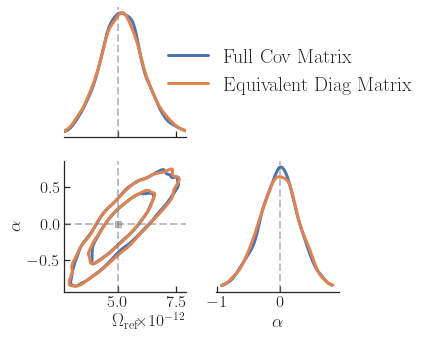

In [53]:
df1 = pd.DataFrame({r'$\Omega_\mathrm{ref}$': Omega_full, r'$\alpha$': alpha_full, 'dataset': r'full'})
df2 = pd.DataFrame({r'$\Omega_\mathrm{ref}$': Omega_original, r'$\alpha$': alpha_original, 'dataset': r'original'})
# Concatenate the datasets
df = pd.concat([df1, df2])

cls = [0.95, 0.68]
p1 = sns.color_palette("light:C0", as_cmap=True)
p2 = sns.color_palette("light:C1", as_cmap=True)
hue_kws = dict(
    levels=[cls, cls],
    fill=[False, False],
    color=['#4c72b0', '#dd8452'],
    linestyles=['-', '-'],
    linewidths=[3, 3],
    alpha=[1, 1],
    zorder=[1, 1]
)
cornerresult = sns.PairGrid(df, vars=[r"$\Omega_\mathrm{ref}$", r"$\alpha$"],
             corner=True,
             palette=['C0', 'C1'],
             hue_kws=hue_kws,
             hue='dataset',
             diag_sharey=False)
cornerresult.map_diag(kdeplot, auto_bound=True, linewidth=3)
cornerresult.map_lower(kdeplot, auto_bound=True, linewidth=3)


diag_index = [0, 3]
joint_index = [2]
diag_truths = [5e-12, 0] 
joint_truths_h = [0]
joint_truths_v = [5e-12]
for i, ax in enumerate(cornerresult.axes.ravel()[joint_index]):
    ax.axvline(joint_truths_v[i], ls='--', linewidth=2, c='gray', alpha=0.5)
    ax.axhline(joint_truths_h[i], ls='--', linewidth=2, c='gray', alpha=0.5)
    ax.plot(joint_truths_v[i], joint_truths_h[i], marker="s", color="gray", alpha=0.5)
    ax.tick_params(direction='in')
for i, ax in enumerate(cornerresult.axes.ravel()[diag_index]):
    ax.axvline(diag_truths[i], ls='--', linewidth=2, c='gray', alpha=0.5)
    ax.tick_params(direction='in')
a = Line2D([0,1],[0,1], linestyle='-', linewidth=3, color='#4c72b0')
b = Line2D([0,1],[0,1], linestyle='-', linewidth=3, color='#dd8452')
#f = Line2D([0,1],[0,1], linestyle='-', linewidth=3, color='#937860')
plt.legend([a, b], [  r"Full Cov Matrix",
                      r"Equivalent Diag Matrix"],
          framealpha=0, edgecolor='w', loc='best',bbox_to_anchor=(3, 2), fontsize=20)

# Fig. 15

In [54]:
import json
import warnings
from os import listdir
from os.path import isfile, join
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.transforms as mt
from astropy.time import Time




from matplotlib import rc



import seaborn as sns

sea = sns.color_palette("tab10")

import numpy as np
from scipy import integrate, stats
from scipy.optimize import curve_fit

import copy

import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import get_window
def get_window_tuple(window_fftgram_dict={"window_fftgram": "hann"}):
    """
    Unpack the `window_fft_dict` dictionary into a `tuple` that may be read by scipy.get_window.

    Parameters:
    ===========
    window_fftgram_dict: dictionary, optional
        Dictionary with window characteristics. Default is `(window_fftgram_dict={"window_fftgram": "hann"}`.

    Returns:
    ========
    window_tuple: tuple
        A tuple containing the window_fft name as the first entry, followed by optional entries of the window_fft_dict.

    Notes:
    ======
    `window_fftgram_dict` is expected to have at least one item, `window_fftgram`.
    """
    window_dict = copy.deepcopy(window_fftgram_dict)
    out = tuple([window_dict["window_fftgram"]])
    window_dict.pop("window_fftgram")
    for name in window_dict:
        if name != "sym":
            out += tuple([window_dict[name]])
    if "sym" in window_fftgram_dict:
        out += tuple([window_dict["sym"]])
    return out
    
def window_factors(N, window_fftgram_dict={"window_fftgram": "hann"}, overlap_factor=0.5):
    """
    Calculate window factors. By default for a hann window with 50% overlap.

    Parameters
    =======
    N: ``int``
        Length of the window.
    window_fftgram_dict: ``dictionary``, optional
        Dictionary with window characteristics. Default is ``window_fftgram_dict={"window_fftgram": "hann"}``
    overlap_factor: ``float``, optional
        Defines the overlap between consecutive data chunks used in the calculation. Default is 0.5.        

    Returns
    =======
    This functions returns the four window factors which correct the analysis for the effect of the window factor.
    w1w2bar: ``float``
    w1w2squaredbar: ``float``
    w1w2ovlbar: ``float``
    w1w2squaredovlbar: ``float``

    See also
    --------
    scipy.signal.get_window
        More information `here <https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.get_window.html>`_.
    """
    window_tuple = get_window_tuple(window_fftgram_dict)
    w = get_window(window_tuple, N, fftbins=False)
    w1w2bar = np.mean(w ** 2)
    w1w2squaredbar = np.mean(w ** 4)

    S = N - int(overlap_factor*N)
    
    if overlap_factor == 0.0 or overlap_factor == 0:
        w1w2squaredovlbar = 0.0
        w1w2ovlbar = 0.0
    else:
        w1w2squaredovlbar = 1 / (N*overlap_factor) * np.sum(w[0:N-S]**2*w[S:N]**2)
        w1w2ovlbar = 1 / (N*overlap_factor) * np.sum(w[0:N-S]*w[S:N])

    return w1w2bar, w1w2squaredbar, w1w2ovlbar, w1w2squaredovlbar

def get_window_tuple(window_fftgram_dict={"window_fftgram": "hann"}):
    """
    Unpack the ``window_fft_dict`` dictionary into a ``tuple`` that can be read by ``scipy.signal.get_window``.

    Parameters
    =======
    window_fftgram_dict: ``dictionary``, optional
        Dictionary with window characteristics. Default is ``window_fftgram_dict={"window_fftgram": "hann"}``.

    Returns
    =======
    window_tuple: ``tuple``
        A tuple containing the window_fft name as the first entry, followed by optional entries of the window_fft_dict.

    Notes
    -----
    ``window_fftgram_dict`` is expected to have at least one item, ``window_fftgram``.
    """
    window_dict = copy.deepcopy(window_fftgram_dict)
    out = tuple([window_dict["window_fftgram"]])
    window_dict.pop("window_fftgram")
    for name in window_dict:
        if name != "sym":
            out += tuple([window_dict[name]])
    if "sym" in window_fftgram_dict:
        out += tuple([window_dict["sym"]])
    return out

In [55]:
def calc_rho1(N, window_fftgram_dict={"window_fftgram": "hann"}, overlap_factor=0.5):
    """
    Calculate the combined window factor rho.

    Parameters
    =======
    N: ``int``
        Length of the window.
    window_fftgram_dict: ``dictionary``, optional
        Dictionary with window characteristics. Default is ``window_fftgram_dict={"window_fftgram": "hann"}``.
    overlap_factor: ``float``, optional
        Defines the overlap between consecutive data chunks used in the calculation. Default is 0.5.

    Returns
    =======
    rho1: ``float``
        The combined window factor.
    """
    w1w2bar, _, w1w2ovlbar, _ = window_factors(N, window_fftgram_dict, overlap_factor=overlap_factor)
    rho1 = (overlap_factor * w1w2ovlbar / w1w2bar) ** 2
    return rho1


def calc_rho(N, j, window_tuple="hann", overlap_factor=0.5):
    """
    Calculate the normalised correlation of a window with itself shifted ``j`` times. This is identical
    to the ``rho(j)`` from Welch (1967).

    Parameters
    =======
    N: ``int``
        Length of the window.
    j: ``int``
        Number of "shifts" to apply to the window when correlating with itself.
    window_tuple: ``str`` or ``tuple``, optional
        Window name or tuple as used in ``scipy.signal.get_window()``. Default is ``window_tuple="hann"``.
    overlap_factor: ``float``, optional
        Defines the overlap between consecutive segments used in the calculation. Default is 0.5.

    Returns
    =======
    rho: ``float``
        The normalised window correlation rho(j).

    See also
    --------
    scipy.signal.get_window
        More information `here <https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.get_window.html>`_.
    """
    # The base window for which we want to calculate the correlation
    w = get_window(window_tuple, N, fftbins=False)
    
    # S is the shift, that is, the number of samples by which the window is shifted from the base window
    S = N - int(overlap_factor*N)
    
    if (j*S < N):
        rho = (np.sum(w[0:N-j*S]*w[j*S:N])/sum(w*w))**2
    else:
        # j*S >= N so no overlap
        rho = 0

    return rho


def effective_welch_averages(nSamples, N, window_tuple="hann", overlap_factor=0.5):
    """
    Calculate the "effective" number of averages used in Welch's PSD estimate after taking into account windowing
    and overlap.

    Parameters
    =======
    nSamples: ``int``
        Number of samples to be used to estimate the PSD.
    N: ``int``
        Length of the window.
    window_tuple: ``str`` or ``tuple``, optional
        Window name or tuple as used in ``scipy.signal.get_window()``. Default is ``window_tuple="hann"``.
    overlap_factor: ``float``, optional
        Defines the overlap between consecutive segments used in the calculation. Default is 0.5.

    Returns
    =======
    Neff: ``float``
        The effective number of averages.
    """
    # S is the shift, that is, the number of samples by which the window is shifted from the base window
    S = N - int(overlap_factor*N)
    
    # K is the number of segments that will be averaged in the corresponding Welch estimate
    K = 1 + int((nSamples - N)/S)

    # Form the weighted sum of the window correlations for shifts j = 1 to K-1
    rho_sum = 0
    for j in range(1, K):
        rho_sum += (K - j)/K*calc_rho(N, j, window_tuple=window_tuple, overlap_factor=overlap_factor)
    
    Neff = K/(1 + 2 * rho_sum)

    return Neff


def calc_bias(
    segmentDuration,
    deltaF,
    deltaT,
    N_avg_segs=2,
    window_fftgram_dict={"window_fftgram": "hann"},
    overlap_factor=0.5
):
    """
    Calculate the bias factor introduced by Welch averaging.

    Parameters
    =======
    segmentDuration: ``float``
        Duration in seconds of Welch-averaged segment.
    deltaF: ``float``
        Frequency resolution (in Hz) of Welch-averaged segment.
    deltaT: ``float``
        Time sampling of Welch-averaged segment (in seconds).
    N_avg_segs: ``int``, optional
        Number of segments over which the average is performed.
    window_fftgram_dict: ``dictionary``, optional
        Dictionary with window characteristics. Default is ``window_fftgram_dict={"window_fftgram": "hann"}``.
    overlap_factor: ``float``, optional
        Defines the overlap between consecutive data chunks used in the calculation. Default is 0.5.

    Returns
    =======
    bias: ``float``
        The bias factor.
    """
    # Number of samples in a data chunk
    nSamples = int(segmentDuration / deltaT)

    # Number of samples in the window used for Welch's estimate
    N = int(1 / (deltaT * deltaF))

    # Effective number of segments that are averaged for this windowing scheme
    window_tuple = get_window_tuple(window_fftgram_dict)
    Neff = effective_welch_averages(nSamples, N, window_tuple, overlap_factor=overlap_factor)

    # if Neff is the same as the true number of segments, no bias.
    if Neff == (nSamples/N):
        bias = 1.0

    else:
        # Correction for number of PSDs that will be averaged 
        Neff = N_avg_segs * Neff
        bias = np.sqrt(1 + 2/Neff)

    return bias

def calc_bias_new(
    segmentDuration,
    deltaF,
    deltaT,
    N_avg_segs=2,
    window_fftgram_dict={"window_fftgram": "hann"},
    overlap_factor=0.5
):
    """
    Calculate the bias factor introduced by Welch averaging.

    Parameters
    =======
    segmentDuration: ``float``
        Duration in seconds of Welch-averaged segment.
    deltaF: ``float``
        Frequency resolution (in Hz) of Welch-averaged segment.
    deltaT: ``float``
        Time sampling of Welch-averaged segment (in seconds).
    N_avg_segs: ``int``, optional
        Number of segments over which the average is performed.
    window_fftgram_dict: ``dictionary``, optional
        Dictionary with window characteristics. Default is ``window_fftgram_dict={"window_fftgram": "hann"}``.
    overlap_factor: ``float``, optional
        Defines the overlap between consecutive data chunks used in the calculation. Default is 0.5.

    Returns
    =======
    bias: ``float``
        The bias factor.
    """
    # Number of samples in a data chunk
    nSamples = int(segmentDuration / deltaT)

    # Number of samples in the window used for Welch's estimate
    N = int(1 / (deltaT * deltaF))

    # Effective number of segments that are averaged for this windowing scheme
    window_tuple = get_window_tuple(window_fftgram_dict)
    Neff = effective_welch_averages(nSamples, N, window_tuple, overlap_factor=overlap_factor)

    # if Neff is the same as the true number of segments, no bias.
    if Neff == (nSamples/N):
        bias = 1.0

    else:
        # Correction for number of PSDs that will be averaged 
        Neff = N_avg_segs * Neff
        bias = np.sqrt(1 + 4/Neff)

    return bias


In [199]:
Y = np.load("./Data/bias_data_paper.npz")['Y']
sigma = np.load("./Data/bias_data_paper.npz")['sigma']
Y_spec = np.load("./Data/bias_data_paper.npz")['Y_spec']
sigma_spec = np.load("./Data/bias_data_paper.npz")['sigma_spec']

100%|██████████| 50/50 [00:01<00:00, 36.99it/s]


0.88
0.08


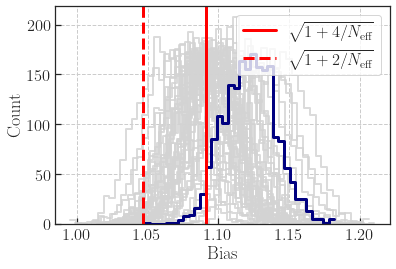

In [241]:
import warnings
warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated")

def bootstrap_bias(signal, sigma, n_boot, rng, chunk=128):
    """Paired bootstrap of std(signal)/mean(sigma)."""
    signal = np.asarray(signal).ravel()
    sigma  = np.asarray(sigma).ravel()
    n = signal.size
    out = np.empty(n_boot)
    for start in range(0, n_boot, chunk):
        stop = min(start + chunk, n_boot)
        idx = rng.integers(0, n, size=(stop - start, n))
        out[start:stop] = signal[idx].std(axis=1) / sigma[idx].mean(axis=1)
    return out

rng = np.random.default_rng(3636)
n_trial, n_boot = 50, 2000

old_bias = calc_bias(192, 1/32, 1/2048)
new_bias = calc_bias_new(192, 1/32, 1/2048)

# ---------- compute ----------
all_results = np.empty((n_trial, n_boot))
for k in tqdm(range(n_trial)):
    f = rng.integers(len(frequencies))
    all_results[k] = bootstrap_bias(Y_spec[:, f], sigma_spec[:, f], n_boot, rng)

result_broad = bootstrap_bias(Y, sigma, n_boot, rng)

lo, hi = np.percentile(all_results, [5, 95], axis=1)
new_bias_cumulated = np.sum((lo <= new_bias) & (new_bias <= hi))
old_bias_cumulated = np.sum((lo <= old_bias) & (old_bias <= hi))

# ---------- plot ----------
for k in range(n_trial):
    sns.histplot(all_results[k], fill=False, element="step",
                 lw=2, color="lightgray", alpha=0.8)

sns.histplot(result_broad, fill=False, element="step", lw=3, color="navy")
plt.axvline(new_bias, color="red", lw=3, label=r"$\sqrt{1+4/N_\mathrm{eff}}$")
plt.axvline(old_bias, color="red", ls="--", lw=3, label=r"$\sqrt{1+2/N_\mathrm{eff}}$")
plt.xlabel(r"Bias")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')
plt.legend()

print(new_bias_cumulated / n_trial)
print(old_bias_cumulated / n_trial)